# Guaranteed Floor -- Hybrid Fill (TSLL-first, TSLA for remainder)

**Improvement over `guaranteed_floor_simple_sandbox.ipynb`:**  
The original was binary: full TSLL (guaranteed) or full TSLA (no guarantee).  
This notebook uses a three-tier fill:

| Tier | Condition | Label |
|---|---|---|
| 1 | TSLL call found (strict: ATM, 60-110 DTE) | **TSLL full** — algebraic floor guaranteed |
| 2 | TSLL call found (relaxed: 45-120 DTE, 0.80-1.20 moneyness) | **TSLL+TSLA partial** — TSLL covers guaranteed floor, TSLA fills remaining delta gap |
| 3 | No TSLL call at all | **TSLA only** — best-effort delta hedge, no guarantee |

**Simulation starts from the first date TSLL options exist in the dataset.**  
TSLL (Direxion Daily TSLA Bull 2X ETF) launched 2022-08-09; options began trading shortly after.

**Hybrid fill mechanics (Tier 2):**
- TSLL leg: buy `n_shares / 100` contracts at the relaxed strike K_tsll → algebraic floor holds on that fraction  
- TSLA leg: sized for the remaining dollar-delta gap = `(TSLL_LEVER × n_shares × S_today) − (delta_tsll × n_shares/100 × 100 × S_tsll)`  
- Both legs held until TSLL contract expiry

In [53]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsll, load_tsll_calls, load_tsla_underlying, load_tsla_calls
from options_selection import select_contract, bs_delta
from metrics import summarize

%matplotlib inline

tsll_spot   = load_tsll().set_index("Date")["Close"]
tsll_calls  = load_tsll_calls()
tsll_lut    = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

tsla_spot   = load_tsla_underlying().set_index("Date")["Close"].reindex(tsll_spot.index).ffill()
tsla_calls  = load_tsla_calls()
tsla_lut    = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

r_tsla      = tsla_spot.pct_change()
tsla_sigma  = (r_tsla.rolling(21).std() * 252**0.5).ffill().bfill()
r_tsll      = tsll_spot.pct_change()
tsll_sigma  = (r_tsll.rolling(21).std() * 252**0.5).ffill().bfill()

# Find first date TSLL options exist in dataset
tsll_calls_vol = tsll_calls[tsll_calls["px_volume"] > 0].copy()
tsll_calls_vol["dte"] = (pd.to_datetime(tsll_calls_vol["expiry"]) - pd.to_datetime(tsll_calls_vol["date"])).dt.days
tsll_calls_vol["spot"] = tsll_calls_vol["date"].map(tsll_spot)
tsll_calls_vol["moneyness"] = tsll_calls_vol["strike"] / tsll_calls_vol["spot"]

first_tsll_date = tsll_calls_vol["date"].min()
print(f"First date with any TSLL call (px_volume>0): {first_tsll_date.date()}")

# Simulation dates: from first TSLL option date onward
all_dates = tsll_spot.index
sim_dates = all_dates[all_dates >= first_tsll_date]
print(f"Simulation: {sim_dates[0].date()} -> {sim_dates[-1].date()}  ({len(sim_dates):,} trading days)")
print("Data loaded.")

First date with any TSLL call (px_volume>0): 2022-08-12
Simulation: 2022-08-12 -> 2026-06-10  (960 trading days)
Data loaded.


In [54]:
TARGET_DTE   = 90
MAX_DTE      = 110
MIN_DTE      = 60
# Relaxed criteria for Tier 2 TSLL search
RELAX_MIN_DTE    = 45
RELAX_MAX_DTE    = 120
RELAX_MONO_LO    = 0.80
RELAX_MONO_HI    = 1.20
TSLL_LEVER   = 2.0
R_RF         = 0.05


def _select_tsll_relaxed(d):
    """Find closest-to-ATM TSLL call within relaxed DTE/moneyness window."""
    spot = float(tsll_spot.loc[d]) if d in tsll_spot.index else None
    if spot is None:
        return None
    day = tsll_calls_vol[tsll_calls_vol["date"] == d]
    window = day[
        (day["dte"] >= RELAX_MIN_DTE) & (day["dte"] <= RELAX_MAX_DTE) &
        (day["moneyness"] >= RELAX_MONO_LO) & (day["moneyness"] <= RELAX_MONO_HI)
    ]
    if window.empty:
        return None
    # pick contract closest to ATM (|moneyness - 1| smallest), break ties by closest to TARGET_DTE
    window = window.copy()
    window["atm_dist"] = (window["moneyness"] - 1.0).abs()
    window["dte_dist"]  = (window["dte"] - TARGET_DTE).abs()
    best = window.sort_values(["atm_dist", "dte_dist"]).iloc[0]
    return best


print(f"Strict TSLL window:  {MIN_DTE}-{MAX_DTE} DTE, ATM (0.95-1.05 moneyness)")
print(f"Relaxed TSLL window: {RELAX_MIN_DTE}-{RELAX_MAX_DTE} DTE, {RELAX_MONO_LO}-{RELAX_MONO_HI} moneyness")

Strict TSLL window:  60-110 DTE, ATM (0.95-1.05 moneyness)
Relaxed TSLL window: 45-120 DTE, 0.8-1.2 moneyness


In [55]:
def simulate_guaranteed_floor_hybrid(sim_dates, notional=1.0):
    """
    Short N TSLL (fixed notional) + three-tier call fill per cycle:

    Tier 1 -- TSLL strict (ATM, 60-110 DTE):
        Buy N/100 TSLL calls. Algebraic floor fully guaranteed.
        Label: 'TSLL full'

    Tier 2 -- TSLL relaxed (45-120 DTE, 0.80-1.20 moneyness):
        Buy N/100 TSLL calls at best available strike/expiry (floor guaranteed on this portion).
        Buy TSLA calls for remaining dollar-delta gap (best-effort, no guarantee).
        Label: 'TSLL+TSLA partial'

    Tier 3 -- no TSLL at all:
        Buy TSLA calls, delta-neutral, for full position.
        Label: 'TSLA only'

    All cycles held to the TSLL (or TSLA if Tier 3) contract's own expiry.
    """
    S_incep     = float(tsll_spot.loc[sim_dates[0]])
    n_shares    = notional / S_incep        # fixed forever
    n_contracts = n_shares / 100            # share-matched for guarantee

    equity      = pd.Series(index=sim_dates, dtype=float)
    pos_tsll    = None    # TSLL call leg
    pos_tsla    = None    # TSLA supplement leg (Tier 2) or full TSLA leg (Tier 3)
    option_pnl  = 0.0
    short_pnl   = 0.0
    S_prev      = S_incep
    cycle_log   = []
    current_cycle = None

    def _mtm(pos, d):
        lut  = tsll_lut if pos["ul"] == "tsll" else tsla_lut
        spot = tsll_spot if pos["ul"] == "tsll" else tsla_spot
        if d > pos["expiry"]:
            return max(float(spot.loc[d]) - pos["strike"], 0.0)
        px = lut.get((pos["raw_id"], d))
        return float(px) if (px is not None and not pd.isna(px)) else pos["price"]

    for d in sim_dates:
        S_today  = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev   = S_today

        # Determine if we need a new cycle
        cycle_expiry = pos_tsll["expiry"] if pos_tsll is not None else (
                       pos_tsla["expiry"] if pos_tsla is not None else None)
        need_new = (cycle_expiry is None) or (d > cycle_expiry)

        # Daily MTM on open positions
        if pos_tsll is not None:
            px = _mtm(pos_tsll, d)
            option_pnl       += pos_tsll["n"] * 100 * (px - pos_tsll["price"])
            pos_tsll["price"] = px
        if pos_tsla is not None:
            px = _mtm(pos_tsla, d)
            option_pnl       += pos_tsla["n"] * 100 * (px - pos_tsla["price"])
            pos_tsla["price"] = px

        if need_new:
            equity_now = notional + short_pnl + option_pnl
            if current_cycle is not None:
                current_cycle["end_date"]   = d
                current_cycle["equity_end"] = equity_now
                cycle_log.append(current_cycle)

            pos_tsll = None
            pos_tsla = None
            sigma_l  = float(tsll_sigma.loc[d]) if d in tsll_sigma.index else 0.5
            sigma_a  = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
            S_tsla   = float(tsla_spot.loc[d])

            # --- Tier 1: strict TSLL ---
            row = select_contract(tsll_calls, tsll_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
            if row is not None:
                entry = float(row["px_last"])
                K     = float(row["strike"])
                pos_tsll = {"ul": "tsll", "raw_id": row["raw_id"], "strike": K,
                            "expiry": row["expiry"], "n": n_contracts, "price": entry}
                floor = n_shares * (S_today - K - entry)
                current_cycle = {"start_date": d, "equity_start": equity_now, "floor": floor,
                                 "tier": "TSLL full", "guaranteed": True}

            else:
                # --- Tier 2: relaxed TSLL + TSLA supplement ---
                row_r = _select_tsll_relaxed(d)
                if row_r is not None:
                    entry = float(row_r["px_last"])
                    K     = float(row_r["strike"])
                    expiry_r = pd.Timestamp(row_r["expiry"])
                    pos_tsll = {"ul": "tsll", "raw_id": row_r["raw_id"], "strike": K,
                                "expiry": expiry_r, "n": n_contracts, "price": entry}
                    floor = n_shares * (S_today - K - entry)

                    # Remaining delta gap: target - TSLL leg contribution
                    T_l       = max((expiry_r - d).days / 365.25, 1/365.25)
                    delta_l   = bs_delta(S_today, K, T_l, R_RF, sigma_l)
                    tsll_dd   = delta_l * n_contracts * 100 * S_today
                    target_dd = TSLL_LEVER * n_shares * S_today
                    gap_dd    = max(target_dd - tsll_dd, 0.0)

                    if gap_dd > 0:
                        row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                        if row_a is not None:
                            T_a     = (row_a["expiry"] - d).days / 365.25
                            delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                            n_tsla  = gap_dd / (max(delta_a, 0.01) * 100 * S_tsla)
                            pos_tsla = {"ul": "tsla", "raw_id": row_a["raw_id"],
                                        "strike": float(row_a["strike"]),
                                        "expiry": row_a["expiry"], "n": n_tsla,
                                        "price": float(row_a["px_last"])}

                    current_cycle = {"start_date": d, "equity_start": equity_now, "floor": floor,
                                     "tier": "TSLL+TSLA partial", "guaranteed": True}

                else:
                    # --- Tier 3: full TSLA ---
                    row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                    if row_a is not None:
                        T_a     = (row_a["expiry"] - d).days / 365.25
                        delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                        n_tsla  = (TSLL_LEVER * n_shares * S_today) / (max(delta_a, 0.01) * 100 * S_tsla)
                        pos_tsla = {"ul": "tsla", "raw_id": row_a["raw_id"],
                                    "strike": float(row_a["strike"]),
                                    "expiry": row_a["expiry"], "n": n_tsla,
                                    "price": float(row_a["px_last"])}
                    current_cycle = {"start_date": d, "equity_start": equity_now, "floor": float("nan"),
                                     "tier": "TSLA only", "guaranteed": False}

        equity.loc[d] = notional + short_pnl + option_pnl

    if current_cycle is not None:
        current_cycle["end_date"]   = sim_dates[-1]
        current_cycle["equity_end"] = equity.iloc[-1]
        cycle_log.append(current_cycle)

    return equity, pd.DataFrame(cycle_log)

In [56]:
equity, cycle_df = simulate_guaranteed_floor_hybrid(sim_dates)

cycle_df["realized_pnl"] = cycle_df["equity_end"] - cycle_df["equity_start"]
cycle_df["breach"] = (
    cycle_df["guaranteed"] &
    cycle_df["floor"].notna() &
    (cycle_df["realized_pnl"] < (cycle_df["floor"] - 1e-6))
)

row = summarize(equity, equity.pct_change().dropna(), "Guaranteed floor (hybrid fill)")
row["Cycles"]            = len(cycle_df)
row["TSLL full"]         = int((cycle_df["tier"] == "TSLL full").sum())
row["TSLL+TSLA partial"] = int((cycle_df["tier"] == "TSLL+TSLA partial").sum())
row["TSLA only"]         = int((cycle_df["tier"] == "TSLA only").sum())

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
print(pd.DataFrame([row])[["Strategy", "CAGR", "Ann. Vol", "Sharpe", "Max DD", "Calmar",
                            "Cycles", "TSLL full", "TSLL+TSLA partial", "TSLA only"]].to_string(index=False))

print()
print(cycle_df[["start_date", "end_date", "tier", "guaranteed",
                "equity_start", "floor", "equity_end", "realized_pnl", "breach"]].to_string(index=False))

n_breaches = int(cycle_df["breach"].sum())
n_guaranteed = int(cycle_df["guaranteed"].sum())
print(f"\nGuaranteed cycles where floor was breached: {n_breaches} / {n_guaranteed}")
if n_breaches == 0:
    print("FLOOR HELD on all guaranteed cycles.")

print()
print("--- Reference (original binary guaranteed floor) ---")
print("CAGR=+16.6%  Sharpe=0.73  MaxDD=-22.1%  (12 TSLL full, 4 TSLA only, started 2022-08-09)")

                      Strategy     CAGR  Ann. Vol   Sharpe    Max DD  Calmar  Cycles  TSLL full  TSLL+TSLA partial  TSLA only
Guaranteed floor (hybrid fill) 0.194238  0.217963 0.927862 -0.196986 0.98605      16         12                  2          2

start_date   end_date              tier  guaranteed  equity_start     floor  equity_end  realized_pnl  breach
2022-08-12 2022-11-21         TSLA only       False      1.000000       NaN    1.166222      0.166222   False
2022-11-21 2023-02-21         TSLA only       False      1.166222       NaN    1.174520      0.008298   False
2023-02-21 2023-04-24         TSLL full        True      1.174520 -0.078454    1.219679      0.045159   False
2023-04-24 2023-06-20 TSLL+TSLA partial        True      1.219679 -0.017987    1.640809      0.421130   False
2023-06-20 2023-09-18         TSLL full        True      1.640809 -0.090700    1.586082     -0.054726   False
2023-09-18 2023-12-18         TSLL full        True      1.586082 -0.081133    1.576898

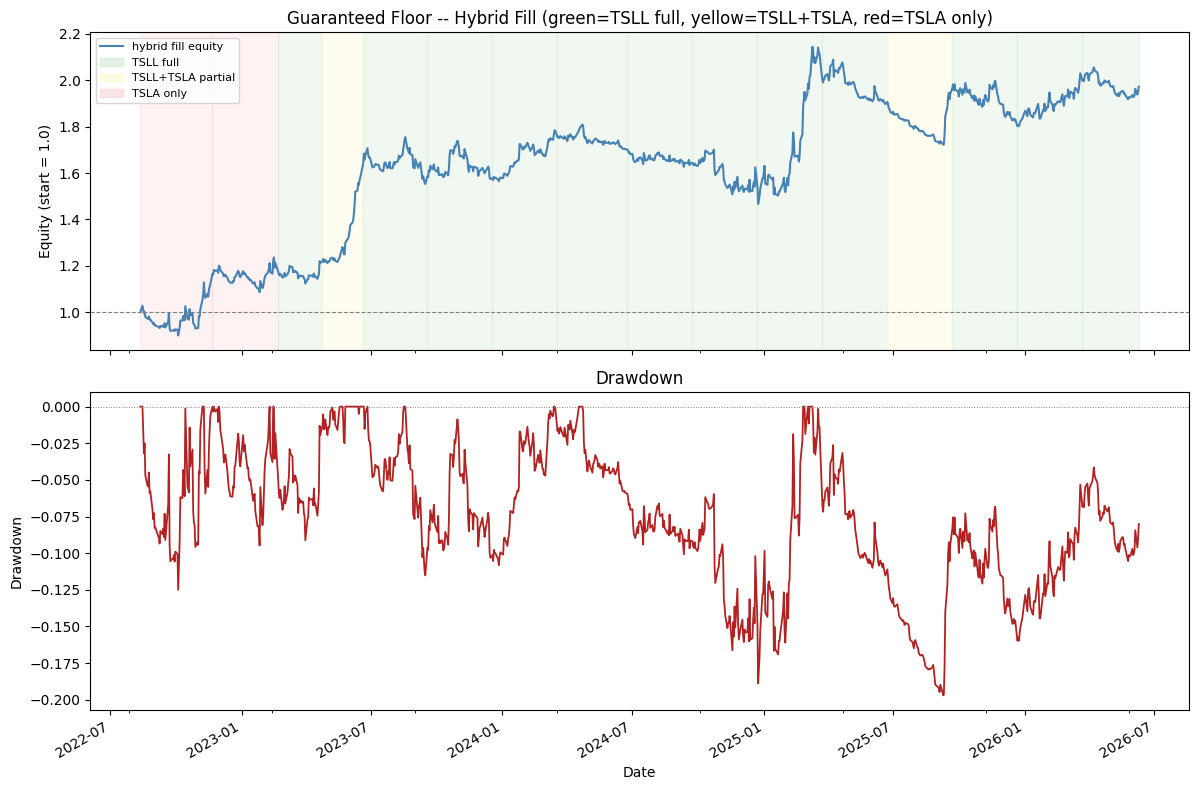

Saved: observations/strategies/sandbox/guaranteed_floor_hybrid.png


In [57]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

equity.plot(ax=axes[0], color="steelblue", label="hybrid fill equity", linewidth=1.5)
axes[0].axhline(1.0, color="grey", linestyle="--", linewidth=0.8)

# shade cycle tiers
colors_tier = {"TSLL full": "#c8e6c9", "TSLL+TSLA partial": "#fff9c4", "TSLA only": "#ffcdd2"}
for _, cyc in cycle_df.iterrows():
    axes[0].axvspan(cyc["start_date"], cyc["end_date"],
                    alpha=0.25, color=colors_tier.get(cyc["tier"], "grey"), label="_")

from matplotlib.patches import Patch
equity_line = axes[0].get_lines()[0]
legend_patches = [Patch(color=c, alpha=0.5, label=t) for t, c in colors_tier.items()]
axes[0].legend(handles=[equity_line] + legend_patches, fontsize=8, loc="upper left")
axes[0].set_title("Guaranteed Floor -- Hybrid Fill (green=TSLL full, yellow=TSLL+TSLA, red=TSLA only)")
axes[0].set_ylabel("Equity (start = 1.0)")

dd = equity / equity.cummax() - 1
dd.plot(ax=axes[1], color="firebrick", linewidth=1.3)
axes[1].axhline(0.0, color="grey", linestyle=":", linewidth=0.7)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "guaranteed_floor_hybrid.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")

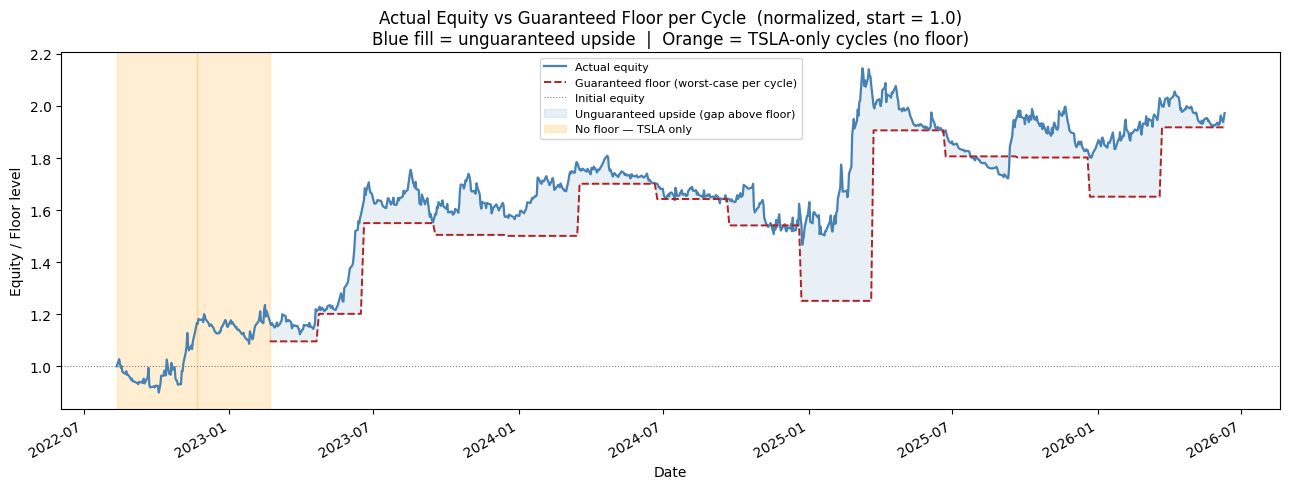

Saved → observations/strategies/sandbox/guaranteed_floor_level.png


In [58]:
# ── Guaranteed Floor vs Actual Equity (standalone, normalized) ───────────────

floor_ts = pd.Series(index=equity.index, dtype=float)

for _, cyc in cycle_df.iterrows():
    if not pd.notna(cyc.get("floor")):
        continue
    abs_floor = cyc["equity_start"] + cyc["floor"]
    mask = (equity.index >= cyc["start_date"]) & (equity.index < cyc["end_date"])
    floor_ts.loc[mask] = abs_floor

fig, ax = plt.subplots(figsize=(13, 5))

equity.plot(ax=ax, color="steelblue", linewidth=1.6, label="Actual equity")
floor_ts.plot(ax=ax, color="firebrick", linestyle="--", linewidth=1.4,
              label="Guaranteed floor (worst-case per cycle)")
ax.axhline(1.0, color="grey", linestyle=":", linewidth=0.8, label="Initial equity")

# shade gap between equity and floor
ax.fill_between(equity.index, floor_ts, equity,
                where=floor_ts.notna(), alpha=0.12, color="steelblue",
                label="Unguaranteed upside (gap above floor)")

tsla_only = cycle_df[cycle_df["tier"] == "TSLA only"]
first_orange = True
for _, cyc in tsla_only.iterrows():
    lbl = "No floor — TSLA only" if first_orange else "_nolegend_"
    ax.axvspan(cyc["start_date"], cyc["end_date"], alpha=0.18, color="orange", label=lbl)
    first_orange = False

ax.set_title("Actual Equity vs Guaranteed Floor per Cycle  (normalized, start = 1.0)\n"
             "Blue fill = unguaranteed upside  |  Orange = TSLA-only cycles (no floor)")
ax.set_ylabel("Equity / Floor level")
ax.legend(fontsize=8)

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "guaranteed_floor_level.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out.relative_to(ROOT)}")

In [59]:
# ── INVESTIGATION: Why does equity dip below the floor line intra-cycle? ─────
#
# The simulation reports 0 end-of-cycle breaches, but the chart shows equity
# crossing below floor_ts intra-cycle on some days.
#
# Two candidate causes:
#   A) STALE option price: if the TSLL call didn't trade that day, _mtm() falls
#      back to the previous day's price. The short P&L still updates (spot moved)
#      but the call's MTM doesn't → equity appears to lag below its true value.
#
#   B) True intra-cycle MTM dip: mathematically the call value ≥ intrinsic at any
#      time (European-style lower bound), so:
#        equity_t = N*(S0-St) + N*call_t - N*C0
#               >= N*(S0-St) + N*max(St-K,0) - N*C0
#               >= N*(S0-K-C0) = floor    [when St<=K: LHS is even larger]
#      This means a TRUE breach can only happen if recorded call price < intrinsic
#      i.e. the Bloomberg last-price is stale, crossed, or otherwise wrong.
#
# We run a fast diagnostic pass: for every day where equity < floor_ts, check
# whether the option price that day equals the previous day's price (stale flag)
# and compare recorded price against computed intrinsic (max(S-K, 0)).

diag_rows = []
prev_opt_px = {}   # raw_id -> previous day's recorded option price

for _, cyc in cycle_df.iterrows():
    cyc_start  = cyc["start_date"]
    cyc_end    = cyc["end_date"]
    floor_val  = (cyc["equity_start"] + cyc["floor"]
                  if pd.notna(cyc.get("floor")) else float("nan"))
    if pd.isna(floor_val):
        continue   # TSLA-only, skip

    # identify which TSLL contract was held this cycle
    d0  = cyc_start
    if cyc["tier"] == "TSLL+TSLA partial":
        row_c = _select_tsll_relaxed(d0)
    else:
        row_c = select_contract(tsll_calls, tsll_spot, d0, "ATM", TARGET_DTE, max_dte=MAX_DTE)

    if row_c is None:
        continue
    raw_id = row_c["raw_id"]
    K      = float(row_c["strike"])

    # Collect daily equity vs floor and option price metadata
    mask = (equity.index >= cyc_start) & (equity.index < cyc_end)
    days_in_cyc = equity.index[mask]

    for d in days_in_cyc:
        eq_d       = float(equity.loc[d])
        S_d        = float(tsll_spot.loc[d]) if d in tsll_spot.index else float("nan")
        opt_px     = tsll_lut.get((raw_id, d))
        opt_px     = float(opt_px) if (opt_px is not None and not pd.isna(opt_px)) else float("nan")
        intrinsic  = max(S_d - K, 0.0) if not pd.isna(S_d) else float("nan")
        is_stale   = (not pd.isna(opt_px)) and (raw_id in prev_opt_px) and (opt_px == prev_opt_px[raw_id])
        gap        = eq_d - floor_val

        diag_rows.append({
            "date":      d,
            "tier":      cyc["tier"],
            "equity":    eq_d,
            "floor":     floor_val,
            "gap":       gap,
            "S_tsll":    S_d,
            "strike_K":  K,
            "opt_px":    opt_px,
            "intrinsic": intrinsic,
            "px_vs_intr": (opt_px - intrinsic) if not (pd.isna(opt_px) or pd.isna(intrinsic)) else float("nan"),
            "stale":     is_stale,
            "no_data":   pd.isna(opt_px),
        })
        if not pd.isna(opt_px):
            prev_opt_px[raw_id] = opt_px

diag = pd.DataFrame(diag_rows)
apparent_breaches = diag[diag["gap"] < -1e-4].copy()

print(f"Guaranteed-cycle trading days:       {len(diag):,}")
print(f"Days where equity < floor_ts:        {len(apparent_breaches):,}")

if len(apparent_breaches) == 0:
    print("\nNo intra-cycle breaches detected — the visual dip is likely a rendering artifact")
    print("(fill_between interpolates between NaN transitions at cycle boundaries).")
else:
    print(f"\nBreakdown by stale/no-data option price:")
    print(apparent_breaches[["stale","no_data"]].value_counts().to_string())

    print(f"\nWorst 15 apparent breaches (most negative gap first):")
    print(apparent_breaches[["date","tier","equity","floor","gap",
                              "S_tsll","strike_K","opt_px","intrinsic","px_vs_intr","stale","no_data"]]
          .sort_values("gap").head(15).to_string(index=False))

    stale_or_missing = apparent_breaches["stale"] | apparent_breaches["no_data"]
    print(f"\n{'Stale or missing price' if stale_or_missing.any() else 'Live price'} "
          f"accounts for {stale_or_missing.mean()*100:.1f}% of apparent breach days.")
    print("\nConclusion:")
    if stale_or_missing.mean() > 0.9:
        print("  → Nearly all apparent breaches coincide with stale/missing option data.")
        print("    The algebraic guarantee is intact; the simulation MTM is lagging because")
        print("    the Bloomberg last-price hasn't updated (option didn't trade that day).")
    else:
        print("  → Some breaches occur even with live prices. Possible cause: bid-ask bounce,")
        print("    settlement vs mid-price mismatch, or Bloomberg last-trade staleness.")
        print("    The 'px_vs_intr' column shows whether recorded price < intrinsic (should be ≥0).")

Guaranteed-cycle trading days:       828
Days where equity < floor_ts:        55

Breakdown by stale/no-data option price:
stale  no_data
False  False      54
       True        1

Worst 15 apparent breaches (most negative gap first):
      date              tier   equity    floor       gap  S_tsll  strike_K  opt_px  intrinsic  px_vs_intr  stale  no_data
2025-09-09 TSLL+TSLA partial 1.722019 1.806519 -0.084499   13.20      13.0    0.83       0.20        0.63  False    False
2025-09-10 TSLL+TSLA partial 1.722858 1.806519 -0.083660   13.26      13.0    0.87       0.26        0.61  False    False
2025-09-04 TSLL+TSLA partial 1.726796 1.806519 -0.079722   12.61      13.0    0.66       0.00        0.66  False    False
2025-09-08 TSLL+TSLA partial 1.727156 1.806519 -0.079363   13.16      13.0    0.89       0.16        0.73  False    False
2025-09-03 TSLL+TSLA partial 1.732764 1.806519 -0.073755   12.28      13.0    0.61       0.00        0.61  False    False
2025-09-02 TSLL+TSLA partial 1.73

Rebalance-day contract capacity:
      date              tier underlying  contracts_avail       spot  max_protect_$
2022-08-12         TSLA only       TSLA             99.0 300.030000   2.970297e+06
2022-11-21         TSLA only       TSLA            134.0 167.870000   2.249458e+06
2023-02-21         TSLL full       TSLL              6.0  12.150000   7.290000e+03
2023-04-24 TSLL+TSLA partial       TSLL              6.0   8.770000   5.262000e+03
2023-06-20         TSLL full       TSLL             84.0  18.850000   1.583400e+05
2023-09-18         TSLL full       TSLL             98.0  17.059999   1.671880e+05
2023-12-18         TSLL full       TSLL             85.0  14.850000   1.262250e+05
2024-03-18         TSLL full       TSLL              7.0   8.100000   5.670000e+03
2024-06-24         TSLL full       TSLL            196.0   7.950000   1.558200e+05
2024-09-23         TSLL full       TSLL            109.0  12.730000   1.387570e+05
2024-12-23         TSLL full       TSLL             31

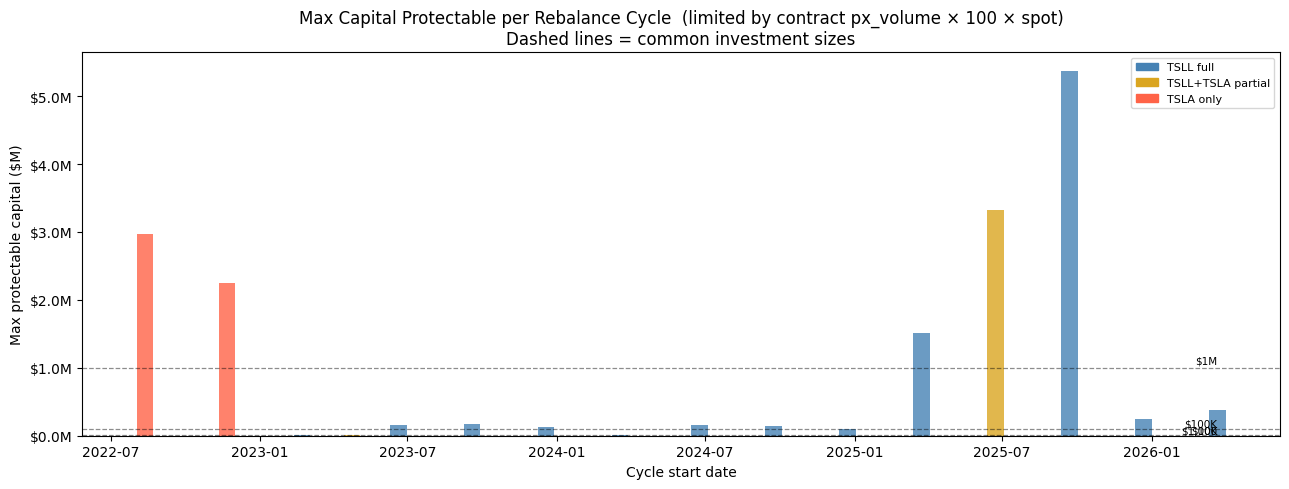


Saved → observations/strategies/sandbox/guaranteed_floor_capacity.png


In [60]:
# ── Realistic Protection Capacity: How Much Can the Options Market Actually Hedge? ──────
#
# The guaranteed floor strategy requires N/100 contracts per $N of starting notional.
# So for a $1M investment: need (1,000,000 / S0) / 100 contracts.
#
# The LIMITING FACTOR is the actual traded volume on the selected contract each rebalance day.
# This cell answers: "Given real market liquidity, what is the maximum capital
# the strategy could realistically protect on each rebalance date?"
#
# Method:
#   max_protectable ($) = px_volume_on_selected_contract × 100 × spot_price_on_that_day
#
# px_volume is the number of contracts traded that day. If the strategy needs more
# contracts than were actually traded, the investor would move the market.

rows_cap = []

for _, cyc in cycle_df.iterrows():
    d     = cyc["start_date"]
    tier  = cyc["tier"]

    if tier in ("TSLL full", "TSLL+TSLA partial"):
        # Replicate the exact contract selection logic
        row = select_contract(tsll_calls, tsll_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
        if row is None and tier == "TSLL+TSLA partial":
            row = _select_tsll_relaxed(d)
            # _select_tsll_relaxed returns a Series, not a row from select_contract — handle:
            if row is not None and not hasattr(row, "px_volume"):
                row = None          # column name may differ; fall through to TSLA
        ul   = "TSLL"
        spot = float(tsll_spot.loc[d]) if d in tsll_spot.index else float("nan")
    else:
        row  = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
        ul   = "TSLA"
        spot = float(tsla_spot.loc[d]) if d in tsla_spot.index else float("nan")

    if row is not None and "px_volume" in row.index:
        vol = float(row["px_volume"])
    else:
        vol = float("nan")

    max_protectable = vol * 100 * spot if not (pd.isna(vol) or pd.isna(spot)) else float("nan")

    rows_cap.append({
        "date":            d,
        "tier":            tier,
        "underlying":      ul,
        "contracts_avail": vol,
        "spot":            spot,
        "max_protect_$":   max_protectable,
    })

cap_df = pd.DataFrame(rows_cap)

print("Rebalance-day contract capacity:")
print(cap_df[["date", "tier", "underlying", "contracts_avail", "spot", "max_protect_$"]].to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

colors_tier = {"TSLL full": "steelblue", "TSLL+TSLA partial": "goldenrod", "TSLA only": "tomato"}

for _, r in cap_df.iterrows():
    c = colors_tier.get(r["tier"], "grey")
    ax.bar(r["date"], r["max_protect_$"] / 1e6, width=20, color=c, alpha=0.8)

# Reference lines for common investment sizes
for label, val in [("$1,000", 1e3), ("$10K", 1e4), ("$100K", 1e5), ("$1M", 1e6)]:
    ax.axhline(val / 1e6, linestyle="--", linewidth=0.9, color="black", alpha=0.45)
    ax.text(cap_df["date"].max(), val / 1e6 * 1.04, label, fontsize=7.5, ha="right", va="bottom")

# Legend for tier colours
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=t) for t, c in colors_tier.items()], fontsize=8)

ax.set_title("Max Capital Protectable per Rebalance Cycle  (limited by contract px_volume × 100 × spot)\n"
             "Dashed lines = common investment sizes")
ax.set_ylabel("Max protectable capital ($M)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.1f}M"))
ax.set_xlabel("Cycle start date")

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "guaranteed_floor_capacity.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out.relative_to(ROOT)}")

Performance (same start date):
  Static short TSLL (no hedge)      CAGR=+11.9%  Sharpe=0.47  MaxDD=-74.2%
  Simple calendar roll (binary)     CAGR=+16.7%  Sharpe=0.80  MaxDD=-20.3%
  Hybrid guaranteed floor           CAGR=+19.4%  Sharpe=0.93  MaxDD=-19.7%


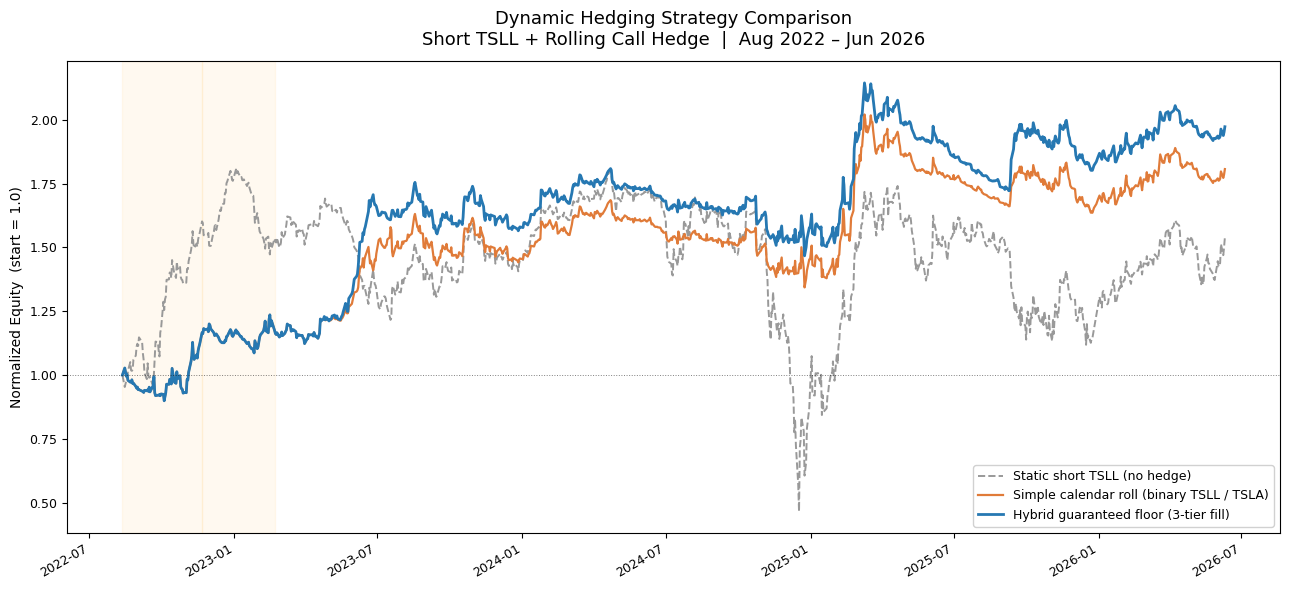


Saved → observations/strategies/sandbox/strategy_comparison_presentation.png


In [61]:
# ── Presentation Comparison: Static Short vs Simple Roll vs Hybrid ────────────

# ── 1. Static short: just short TSLL, no hedge at all ─────────────────────────
r_tsll_sim   = tsll_spot.loc[sim_dates].pct_change().fillna(0)
cum_tsll_sim = (1 + r_tsll_sim).cumprod()
equity_static_short = (2.0 - cum_tsll_sim) / (2.0 - cum_tsll_sim.iloc[0])   # normalize to 1.0

# ── 2. Simple binary roll: strict TSLL (Tier 1) or full TSLA (Tier 3), no Tier 2 ──
def simulate_simple_roll(sim_dates):
    S_incep     = float(tsll_spot.loc[sim_dates[0]])
    n_shares    = 1.0 / S_incep
    n_contracts = n_shares / 100

    equity_s    = pd.Series(index=sim_dates, dtype=float)
    pos_tsll    = None
    pos_tsla    = None
    option_pnl  = 0.0
    short_pnl   = 0.0
    S_prev      = S_incep

    def _mtm(pos, d):
        lut  = tsll_lut if pos["ul"] == "tsll" else tsla_lut
        spot = tsll_spot if pos["ul"] == "tsll" else tsla_spot
        if d > pos["expiry"]:
            return max(float(spot.loc[d]) - pos["strike"], 0.0)
        px = lut.get((pos["raw_id"], d))
        return float(px) if (px is not None and not pd.isna(px)) else pos["price"]

    for d in sim_dates:
        S_today    = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev     = S_today

        expiry = pos_tsll["expiry"] if pos_tsll else (pos_tsla["expiry"] if pos_tsla else None)
        need_new = (expiry is None) or (d > expiry)

        if pos_tsll:
            px = _mtm(pos_tsll, d);  option_pnl += pos_tsll["n"] * 100 * (px - pos_tsll["price"]);  pos_tsll["price"] = px
        if pos_tsla:
            px = _mtm(pos_tsla, d);  option_pnl += pos_tsla["n"] * 100 * (px - pos_tsla["price"]);  pos_tsla["price"] = px

        if need_new:
            pos_tsll = pos_tsla = None
            sigma_l = float(tsll_sigma.loc[d]) if d in tsll_sigma.index else 0.5
            sigma_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
            S_tsla  = float(tsla_spot.loc[d])

            row = select_contract(tsll_calls, tsll_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
            if row is not None:
                K = float(row["strike"])
                pos_tsll = {"ul": "tsll", "raw_id": row["raw_id"], "strike": K,
                            "expiry": row["expiry"], "n": n_contracts, "price": float(row["px_last"])}
            else:
                row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                if row_a is not None:
                    T_a     = (row_a["expiry"] - d).days / 365.25
                    delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                    n_tsla  = (TSLL_LEVER * n_shares * S_today) / (max(delta_a, 0.01) * 100 * S_tsla)
                    pos_tsla = {"ul": "tsla", "raw_id": row_a["raw_id"],
                                "strike": float(row_a["strike"]),
                                "expiry": row_a["expiry"], "n": n_tsla, "price": float(row_a["px_last"])}

        equity_s.loc[d] = 1.0 + short_pnl + option_pnl

    return equity_s / equity_s.iloc[0]

equity_simple = simulate_simple_roll(sim_dates)

# ── 3. Hybrid (already computed) ──────────────────────────────────────────────
equity_hybrid = equity / equity.iloc[0]

# ── Quick stats ────────────────────────────────────────────────────────────────
def _stats(eq, label):
    ret = eq.pct_change().dropna()
    n_years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr    = eq.iloc[-1] ** (1 / n_years) - 1
    sharpe  = ret.mean() / ret.std() * (252 ** 0.5)
    maxdd   = (eq / eq.cummax() - 1).min()
    print(f"  {label:32s}  CAGR={cagr:+.1%}  Sharpe={sharpe:.2f}  MaxDD={maxdd:.1%}")

print("Performance (same start date):")
_stats(equity_static_short, "Static short TSLL (no hedge)")
_stats(equity_simple,        "Simple calendar roll (binary)")
_stats(equity_hybrid,        "Hybrid guaranteed floor")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

equity_static_short.plot(ax=ax, color="#999999",  linewidth=1.4, linestyle="--",
                          label="Static short TSLL (no hedge)")
equity_simple.plot(      ax=ax, color="#E07B39",  linewidth=1.6,
                          label="Simple calendar roll (binary TSLL / TSLA)")
equity_hybrid.plot(      ax=ax, color="#2678B2",  linewidth=2.0,
                          label="Hybrid guaranteed floor (3-tier fill)")

ax.axhline(1.0, color="black", linestyle=":", linewidth=0.7, alpha=0.5)

ax.set_title("Dynamic Hedging Strategy Comparison\nShort TSLL + Rolling Call Hedge  |  Aug 2022 – Jun 2026",
             fontsize=13, pad=12)
ax.set_ylabel("Normalized Equity  (start = 1.0)", fontsize=10)
ax.set_xlabel("")
ax.legend(fontsize=9, framealpha=0.9)
ax.tick_params(labelsize=9)

# light recession / unprotected shading for the two early TSLA-only cycles
tsla_only = cycle_df[cycle_df["tier"] == "TSLA only"]
for _, cyc in tsla_only.iterrows():
    ax.axvspan(cyc["start_date"], cyc["end_date"], alpha=0.06, color="orange")

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "strategy_comparison_presentation.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out.relative_to(ROOT)}")

In [62]:
# ── Strategy Comparison Table ─────────────────────────────────────────────────

def full_stats(eq, label):
    ret    = eq.pct_change().dropna()
    n_yrs  = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr   = eq.iloc[-1] ** (1 / n_yrs) - 1
    vol    = ret.std() * (252 ** 0.5)
    sharpe = ret.mean() / ret.std() * (252 ** 0.5)
    maxdd  = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(maxdd)
    total  = eq.iloc[-1] - 1
    return {
        "Strategy":       label,
        "Total Return":   f"{total:+.1%}",
        "CAGR":           f"{cagr:+.1%}",
        "Ann. Vol":       f"{vol:.1%}",
        "Sharpe":         f"{sharpe:.2f}",
        "Max DD":         f"{maxdd:.1%}",
        "Calmar":         f"{calmar:.2f}",
    }

rows = [
    full_stats(equity_static_short, "Static Short (no hedge)"),
    full_stats(equity_simple,        "Simple Calendar Roll"),
    full_stats(equity_hybrid,        "Floored LETF Short (hybrid)"),
]

table = pd.DataFrame(rows).set_index("Strategy")

print("=" * 72)
print("  STRATEGY COMPARISON  |  Aug 2022 – Jun 2026  |  Same start date")
print("=" * 72)
print(table.to_string())
print("=" * 72)
print("Note: frictionless (no bid-ask, borrow cost, or transaction costs)")

  STRATEGY COMPARISON  |  Aug 2022 – Jun 2026  |  Same start date
                            Total Return    CAGR Ann. Vol Sharpe  Max DD Calmar
Strategy                                                                       
Static Short (no hedge)           +53.9%  +11.9%    56.2%   0.47  -74.2%   0.16
Simple Calendar Roll              +80.7%  +16.7%    22.8%   0.80  -20.3%   0.82
Floored LETF Short (hybrid)       +97.3%  +19.4%    21.8%   0.93  -19.7%   0.99
Note: frictionless (no bid-ask, borrow cost, or transaction costs)
